In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

import pybamm

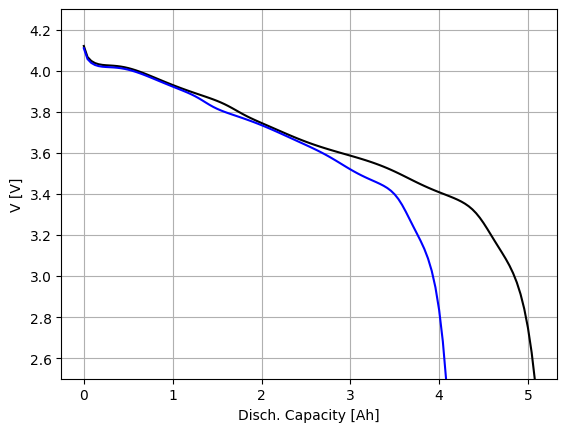

In [3]:
param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 0.5C for 100000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1)

t = solution["Time [s]"].entries

V = solution["Terminal voltage [V]"].entries

plt.figure()
plt.grid()
plt.plot(t / 3600. * 0.5 * 5., V, "k-")
plt.ylim([2.5, 4.3])
plt.xlabel("Disch. Capacity [Ah]")
plt.ylabel("V [V]")

param = pybamm.ParameterValues("Chen2020")
param["Negative electrode active material volume fraction"] *= 0.8

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 0.5C for 100000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1)

t = solution["Time [s]"].entries

V = solution["Terminal voltage [V]"].entries

plt.plot(t / 3600. * 0.5 * 5., V, "b-")
plt.ylim([2.5, 4.3])
plt.xlabel("Disch. Capacity [Ah]")
plt.ylabel("V [V]")
plt.show()

In [12]:
V

array([4.10954675, 4.05679273, 4.03818478, 4.02806834, 4.02251124,
       4.01959737, 4.01808733, 4.01710836, 4.01604696, 4.0144931 ,
       4.01220042, 4.00905172, 4.00502682, 4.00017605, 3.99459282,
       3.98839479, 3.98170863, 3.97465908, 3.96736164, 3.95991801,
       3.95241319, 3.94491569, 3.93747054, 3.93010699, 3.9228302 ,
       3.91561668, 3.90840614, 3.90108796, 3.89348759, 3.88536292,
       3.87644029, 3.86652885, 3.85570749, 3.84445507, 3.83350849,
       3.82348987, 3.81463853, 3.80684482, 3.799837  , 3.79333383,
       3.78710804, 3.78099445, 3.77487712, 3.76867522, 3.76233155,
       3.75580525, 3.74906849, 3.74210448, 3.73490702, 3.72748055,
       3.71984011, 3.7120104 , 3.70402397, 3.6959188 , 3.68773453,
       3.67950811, 3.67126929, 3.66303619, 3.65481172, 3.64658106,
       3.63831053, 3.62994832, 3.62142739, 3.61267109, 3.60360182,
       3.59415302, 3.58428363, 3.57399294, 3.56333213, 3.55240798,
       3.54137489, 3.53041511, 3.51971079, 3.50941525, 3.49963

In [4]:
from scr.SPMe import Solid_Phase, Cell
from scr.utils.pinn import NN_TL_Diffusion
from scr.utils.sampling import Sampler, Sampler_DONet
from scr.utils.parameters import load_params
from scr.utils.profiles import zheng_current, constant

import numpy as np
import torch

In [5]:
def RMSELoss(yhat, y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [6]:
parameters = load_params()
pos_weights = {"PDE": 1e4, "IV": 10., "BC_Center": 1., "BC_Surf": 1e4}
neg_weights = {"PDE": 1e4, "IV": 10., "BC_Center": 1., "BC_Surf": 1e4}

model_p = NN_TL_Diffusion(general_layers=[64, 64, 64, 64], fine_layers=[32, 32], dim_in=3, dim_int=32,
                            dim_out=1, dropout=0.)
optimizer_p = torch.optim.Adam(model_p.parameters(), lr=0.0005)
pos_model = Solid_Phase(model_p, parameters, criterion=RMSELoss, electrode="pos", weights=pos_weights)
model_n = NN_TL_Diffusion(general_layers=[64, 64, 64, 64], fine_layers=[32, 32], dim_in=3, dim_int=32,
                        dim_out=1, dropout=0.)
optimizer_n = torch.optim.Adam(model_n.parameters(), lr=0.0005)
neg_model = Solid_Phase(model_n, parameters, criterion=RMSELoss, electrode="neg", weights=neg_weights)

PINN = Cell(pos_model, neg_model)

PINN.pos_model.load_model("../models/TL_pos.pt")
PINN.neg_model.load_model("../models/TL_neg.pt")

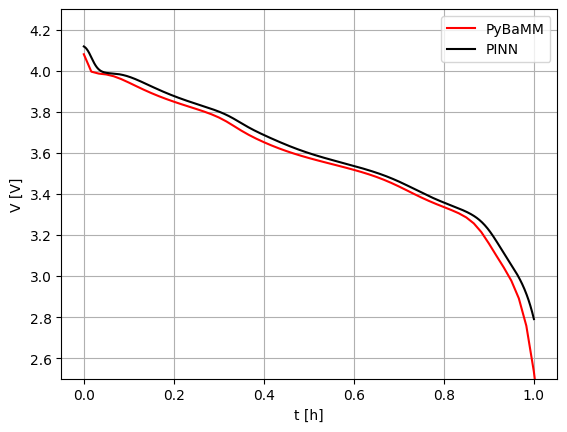

In [10]:
t_eval = np.arange(0, 3600)
cur_fun = constant(1.)

bcs_sample_t = torch.linspace(0., 1., 1000)
bcs_sample_r = torch.ones_like(bcs_sample_t)
bcs_sample_I = torch.tensor(cur_fun(bcs_sample_t.numpy() * 3600.))
bcs_sample = torch.stack([bcs_sample_t, bcs_sample_r, bcs_sample_I]).t()

V_pinn = PINN.compute_V(bcs_sample).detach().numpy()


param = pybamm.ParameterValues("Chen2020")
PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Discharge at 1C for 100000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=1)

t = solution["Time [s]"].entries

V = solution["Terminal voltage [V]"].entries

plt.figure()
plt.grid()
plt.plot(t / 3600., V, "r-", label="PyBaMM")
plt.plot(bcs_sample_t, V_pinn, "k-", label="PINN")
plt.ylim([2.5, 4.3])
plt.xlabel("t [h]")
plt.ylabel("V [V]")
plt.legend()
plt.show()